In [37]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join("../")))

import numpy as np
import matplotlib.pyplot as plt

from src.simulation import Simulation
from src.config import Config
from src.layers import create_layers_from_interfaces

from src.plot.plot_tools import set_plot_style, plot_seismogram
set_plot_style()

In [38]:
# --- Load binaries from TOYxDAC Time ---
scenario = 2
free_surface = True

scenarios = {
    1: ("vp_v1", {
        True:  "seis_v1_fs",
        False: "seis_v1_nofs"
    }),
    2: ("vp_v2", {
        True:  "seis_v2_fs",
        False: "seis_v2_nofs"
    })
}

if scenario in scenarios:
    data_path, files = scenarios[scenario]
    data = np.fromfile('data/' + data_path, dtype=np.float32)
    file = files[free_surface]
    print(f"Loaded scenario {scenario}: {data_path} | File: {file}")
else:
    print(f"Error: Scenario {scenario} is not defined.")

Loaded scenario 2: vp_v2 | File: seis_v2_fs


In [39]:
ngrid = 141
z_coord = np.linspace(0.0, 700.0, ngrid)
x_coord = np.linspace(0.0, 700.0, ngrid)

medium = data.reshape((ngrid, ngrid)).T
nt = 2048  # Number of time steps
nr = 57    # Number of receivers

# Load, reshape, and transpose to (Time, Receiver)
seismo_fd = np.fromfile('data/' + file, dtype=np.float32).reshape((nr, nt)).T
time = np.linspace(0, 1.024, nt)
receiver_coord = np.linspace(0.0, 700.0, nr)

# normalize
max = np.max(np.abs(seismo_fd))
seismo_fd = seismo_fd / max

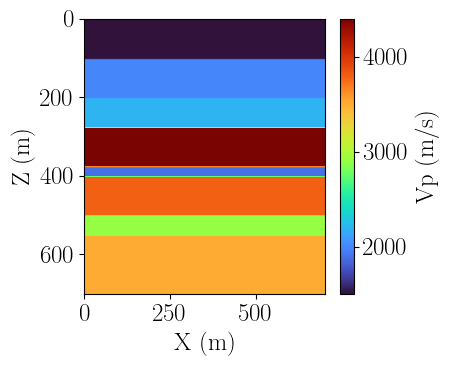

In [40]:
plt.figure(figsize=(4.75, 4))
plt.imshow(
    medium,
    extent=(x_coord.min(), x_coord.max(), 
            z_coord.max(), z_coord.min()),
    aspect='auto',
    cmap='turbo',
)
plt.colorbar(label="Vp (m/s)")
plt.xlabel("X (m)")
plt.ylabel("Z (m)")
plt.tight_layout()
plt.show()

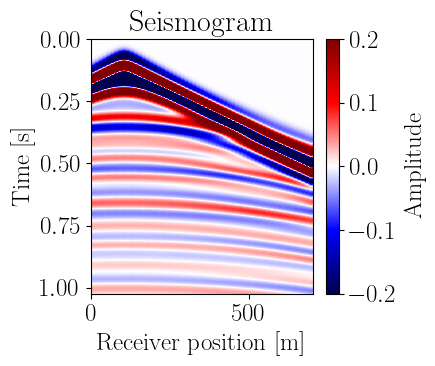

In [41]:
plot_seismogram(seismo_fd, receiver_coord, time, vmin=-0.2, vmax=0.2, cmap='seismic', ncolors=256, figsize=(4.5, 4))

In [42]:
config = Config(
    n_receivers=57, x_min=0., x_max=700.,
    z_rec=75., z_src=50., x_src=100., nq_prop=1024, f0=10.,
    total_time=1.024, delay=0.1, epsilon=1.0,
    source_deriv=True, free_surface=free_surface,
)
sim = Simulation(config)

# Scenario-specific velocity structures
if scenario == 1:
    z_int = np.array([0.0, 100.0, 200.0, 250.0, 350.0, 450.0, 550.0, 650.0, 700.0])
    vp    = np.array([1505.0, 1603.0, 1749.0, 2019.0, 2179.0, 1900.0, 2265.0, 3281.0])
elif scenario == 2:
    z_int = np.array([0.0, 100.0, 200.0, 275.0, 375.0, 400.0, 500.0, 550.0, 700.0])
    vp    = np.array([1505.0, 2000.0, 2200.0, 4400.0, 1900.0, 3800.0, 2900.0, 3500.0])

# Constant density for all layers
rho = np.full_like(vp, 2000.0)
layers = create_layers_from_interfaces(z_int, vp, rho)
d_cal, _ = sim.forward(layers)
# Normalization
d_cal /= np.abs(d_cal).max()

In [43]:
nt_ref = sim.param.nt
# Reshape to (Receiver, Time) and normalize
ref = d_cal.reshape((nr, nt_ref))

time_ref = np.linspace(0, 1.024, nt_ref)
t0 = 0.6
mask = time > t0
dt = time[1] - time[0]

# --- Error Analysis ---
err_abs = np.zeros(nr)
err_L2  = np.zeros(nr)

for i in range(nr):
    # Interpolate reflectivity to match FD time sampling
    trace_ref_interp = np.interp(time, time_ref, ref[i, :])
    # Calculate residual
    trace_fd = seismo_fd[:, i]
    residual = trace_ref_interp - trace_fd
    # Error Metrics
    err_abs[i] = np.abs(residual).max()
    err_L2[i]  = np.sqrt(np.sum(residual[mask]**2) * dt)

max_recv_ind   = np.argmax(err_abs)
max_recv_indL2 = np.argmax(err_L2)
mask_count = np.sum(mask)
# Reporting
print(f"Max Absolute error: {err_abs[max_recv_ind]:.6f} at receiver {max_recv_ind}")
print(f"Max L2 error:       {err_L2[max_recv_indL2]:.6f} at receiver {max_recv_indL2}")
print(f"L2 Mask applied:    t > {t0}s ({mask_count} samples)")

Max Absolute error: 0.068350 at receiver 43
Max L2 error:       0.005873 at receiver 45
L2 Mask applied:    t > 0.6s (848 samples)


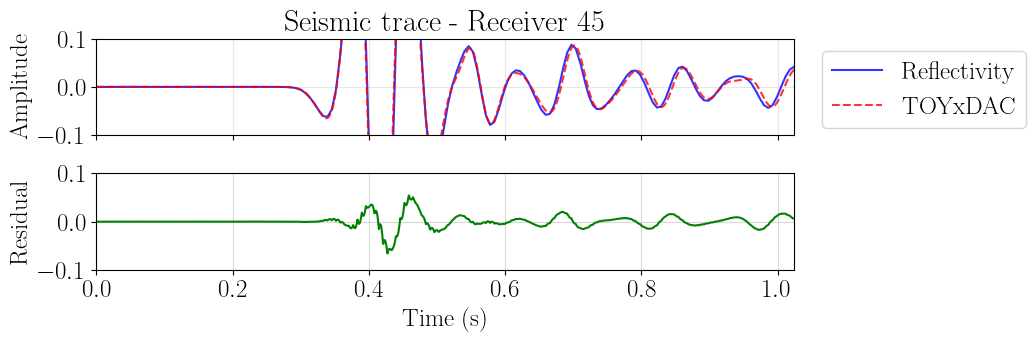

In [44]:
# --- Comparison Plotting ---
target_idx = max_recv_indL2

# Re-calculate specific traces for the target receiver
trace_ref_plot = np.interp(time, time_ref, ref[target_idx, :])
trace_fd_plot  = seismo_fd[:, target_idx]
residual_plot  = trace_ref_plot - trace_fd_plot

# Setup Figure
fig, axes = plt.subplots(2, 1, figsize=(9, 3), sharex=True)
plt.subplots_adjust(hspace=0.4)

# Plot 1: Comparison
axes[0].plot(time, trace_ref_plot, 'b-', alpha=0.8, label='Reflectivity')
axes[0].plot(time, trace_fd_plot, 'r--', alpha=0.8, label='TOYxDAC')
axes[0].set_title(f"Seismic trace - Receiver {target_idx}")
axes[0].set_ylabel("Amplitude")
axes[0].legend(loc='upper right', bbox_to_anchor=(1.35, 1))
axes[0].grid(True, alpha=0.3)

# Plot 2: Residual
axes[1].plot(time, residual_plot, 'g-', label='Residual')
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Residual")
axes[1].grid(True, alpha=0.5)

# Global styling
for ax in axes:
    ax.set_xlim(0, 1.024)
    ax.set_ylim(-0.1, 0.1)
plt.show()